In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Datasets

In [3]:
patients = pd.read_csv('Patients.csv')
encounters = pd.read_csv('encounter.csv')          
payers = pd.read_csv('payers.csv')
procedures = pd.read_csv('procedures.csv')
organizations = pd.read_csv('organizations.csv')

In [4]:
dataframes = {
    'patients':patients,
    'encounter':encounters,
    'payers':payers,
    'organisations':organizations,
    'procedures':procedures
}
for name,df in dataframes.items():
    print(f"==={name} ===")
    print(f"shape:{df.shape}")
    print(f"columns:{df.columns}")
    print(f"Duplicate values:{df.duplicated().sum()}")
    print(f"Null Values:{df.isnull().sum()}")
    print(df.info())
    print("\n")

===patients ===
shape:(974, 20)
columns:Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX',
       'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE',
       'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON'],
      dtype='object')
Duplicate values:0
Null Values:Id              0
BIRTHDATE       0
DEATHDATE     820
PREFIX          0
FIRST           0
LAST            0
SUFFIX        953
MAIDEN        588
MARITAL         1
RACE            0
ETHNICITY       0
GENDER          0
BIRTHPLACE      0
ADDRESS         0
CITY            0
STATE           0
COUNTY          0
ZIP           142
LAT             0
LON             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PRE

In [5]:
# cleaning column names

for name, df in dataframes.items():
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    print(f"{name}: {list(df.columns)}")

patients: ['id', 'birthdate', 'deathdate', 'prefix', 'first', 'last', 'suffix', 'maiden', 'marital', 'race', 'ethnicity', 'gender', 'birthplace', 'address', 'city', 'state', 'county', 'zip', 'lat', 'lon']
encounter: ['id', 'start', 'stop', 'patient', 'organization', 'payer', 'encounterclass', 'code', 'description', 'base_encounter_cost', 'total_claim_cost', 'payer_coverage', 'reasoncode', 'reasondescription']
payers: ['id', 'name', 'address', 'city', 'state_headquartered', 'zip', 'phone']
organisations: ['id', 'name', 'address', 'city', 'state', 'zip', 'lat', 'lon']
procedures: ['start', 'stop', 'patient', 'encounter', 'code', 'description', 'base_cost', 'reasoncode', 'reasondescription']


In [6]:
# Patients: Handling null values 
# 1. Deceased flag 
patients['is_deceased'] = patients['deathdate'].notna().astype(int)

# 2. Useless columns drop 
patients.drop(columns=['suffix', 'maiden', 'address', 'birthplace'], inplace=True)

# 3. Marital 1 null fill
patients['marital'].fillna(patients['marital'].mode()[0], inplace=True)

# 4. ZIP fix 
patients['zip'] = patients['zip'].fillna(0).astype(int).astype(str)

# verifying
print("Nulls remaining:")
print(patients.isnull().sum())
print("\nShape:", patients.shape)

Nulls remaining:
id               0
birthdate        0
deathdate      820
prefix           0
first            0
last             0
marital          0
race             0
ethnicity        0
gender           0
city             0
state            0
county           0
zip              0
lat              0
lon              0
is_deceased      0
dtype: int64

Shape: (974, 17)


C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\568697274.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patients['marital'].fillna(patients['marital'].mode()[0], inplace=True)


In [7]:
# Patients: Date columns fix 
# Converting Date columns datetime 
patients['birthdate'] = pd.to_datetime(patients['birthdate'])
patients['deathdate'] = pd.to_datetime(patients['deathdate'], errors='coerce')

# Age calculation
today = pd.Timestamp('today')
patients['age'] = ((today - patients['birthdate']).dt.days / 365.25).astype(int)

# Verifying
print(patients[['birthdate', 'deathdate', 'age']].head())
print("\nAge stats:")
print(patients['age'].describe().round(1))

   birthdate  deathdate  age
0 1977-03-19        NaT   49
1 1940-02-19        NaT   86
2 1958-06-04        NaT   68
3 1928-12-25 2017-09-29   97
4 1928-12-25 2014-02-23   97

Age stats:
count    974.0
mean      73.9
std       20.5
min       34.0
25%       56.0
50%       76.0
75%       93.0
max      104.0
Name: age, dtype: float64


C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\89705752.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  patients['birthdate'] = pd.to_datetime(patients['birthdate'])
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\89705752.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  patients['deathdate'] = pd.to_datetime(patients['deathdate'], errors='coerce')


In [8]:
# Patients: Feature Engineering
# Age group
bins   = [0, 40, 55, 70, 85, 110]
labels = ['Young (0-40)', 'Middle-Aged (41-55)', 'Senior (56-70)', 
          'Elderly (71-85)', 'Very Elderly (85+)']
patients['age_group'] = pd.cut(patients['age'], bins=bins, labels=labels, right=True)

# Gender full form
patients['gender_full'] = patients['gender'].map({'M': 'Male', 'F': 'Female'})

# Marital full form
patients['marital_full'] = patients['marital'].map({'M': 'Married', 'S': 'Single'})

# Patient status
patients['patient_status'] = patients['is_deceased'].map({0: 'Alive', 1: 'Deceased'})

# Verifying
print(patients[['age', 'age_group', 'gender_full', 'marital_full', 'patient_status']].head(8))
print("\nAge group distribution:")
print(patients['age_group'].value_counts().sort_index())

   age            age_group gender_full marital_full patient_status
0   49  Middle-Aged (41-55)      Female      Married          Alive
1   86   Very Elderly (85+)        Male      Married          Alive
2   68       Senior (56-70)        Male      Married          Alive
3   97   Very Elderly (85+)        Male      Married       Deceased
4   97   Very Elderly (85+)        Male      Married       Deceased
5   97   Very Elderly (85+)        Male      Married          Alive
6   68       Senior (56-70)      Female      Married          Alive
7   54  Middle-Aged (41-55)        Male      Married          Alive

Age group distribution:
age_group
Young (0-40)            61
Middle-Aged (41-55)    179
Senior (56-70)         173
Elderly (71-85)        198
Very Elderly (85+)     363
Name: count, dtype: int64


In [9]:
# Encounters: Dates fix 
# Dates conversion
encounters['start'] = pd.to_datetime(encounters['start'])
encounters['stop']  = pd.to_datetime(encounters['stop'])

# Getting Time features 
encounters['year']    = encounters['start'].dt.year
encounters['month']   = encounters['start'].dt.month
encounters['quarter'] = encounters['start'].dt.quarter
encounters['weekday'] = encounters['start'].dt.day_name()

# Verifying
print(encounters[['start', 'stop', 'year', 'month', 'quarter', 'weekday']].head())
print("\nYear range:", encounters['year'].min(), "to", encounters['year'].max())

                      start                      stop  year  month  quarter  \
0 2011-01-02 09:26:36+00:00 2011-01-02 12:58:36+00:00  2011      1        1   
1 2011-01-03 05:44:39+00:00 2011-01-03 06:01:42+00:00  2011      1        1   
2 2011-01-03 14:32:11+00:00 2011-01-03 14:47:11+00:00  2011      1        1   
3 2011-01-03 16:24:45+00:00 2011-01-03 16:39:45+00:00  2011      1        1   
4 2011-01-03 17:36:53+00:00 2011-01-03 17:51:53+00:00  2011      1        1   

  weekday  
0  Sunday  
1  Monday  
2  Monday  
3  Monday  
4  Monday  

Year range: 2011 to 2022


In [10]:
# Encounters: Handling Null values 
# Reasondescription nulls fill 
encounters['reasondescription'].fillna('General / No Specific Reason', inplace=True)
encounters['reasoncode'].fillna(0, inplace=True)

# Verifying
print("Nulls remaining:")
print(encounters.isnull().sum())
print("\nReasonDescription sample:")
print(encounters['reasondescription'].value_counts().head(10))

Nulls remaining:
id                     0
start                  0
stop                   0
patient                0
organization           0
payer                  0
encounterclass         0
code                   0
description            0
base_encounter_cost    0
total_claim_cost       0
payer_coverage         0
reasoncode             0
reasondescription      0
year                   0
month                  0
quarter                0
weekday                0
dtype: int64

ReasonDescription sample:
reasondescription
General / No Specific Reason                   19541
Chronic congestive heart failure (disorder)     1738
Hyperlipidemia                                  1565
Normal pregnancy                                1341
Viral sinusitis (disorder)                       732
Malignant neoplasm of breast (disorder)          723
Acute viral pharyngitis (disorder)               400
Acute bronchitis (disorder)                      352
Alzheimer's disease (disorder)                   19

C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\1742760215.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  encounters['reasondescription'].fillna('General / No Specific Reason', inplace=True)
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\1742760215.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [11]:
# Encounters: Feature Engineering
# 1. Duration in hours
encounters['duration_hours'] = (
    (encounters['stop'] - encounters['start']).dt.total_seconds() / 3600
).round(2)

# 2. Duration bucket
encounters['duration_bucket'] = pd.cut(
    encounters['duration_hours'],
    bins=[-1, 1, 8, 24, float('inf')],
    labels=['< 1 hr', '1-8 hrs', '8-24 hrs', '24+ hrs']
)

# 3. Out of pocket cost
encounters['out_of_pocket'] = (
    encounters['total_claim_cost'] - encounters['payer_coverage']
).clip(lower=0).round(2)

# 4. Coverage ratio
encounters['coverage_ratio'] = (
    encounters['payer_coverage'] / encounters['total_claim_cost'].replace(0, np.nan)
).round(4).fillna(0)

# 5. High cost flag
q75 = encounters['total_claim_cost'].quantile(0.75)
encounters['is_high_cost'] = (encounters['total_claim_cost'] > q75).astype(int)

# 6. Zero coverage flag
encounters['zero_coverage'] = (encounters['payer_coverage'] == 0).astype(int)

# 7. Season
def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Fall'

encounters['season'] = encounters['month'].apply(get_season)

# 8. Weekend flag
encounters['is_weekend'] = encounters['start'].dt.dayofweek.isin([5, 6]).astype(int)

# Verifying
print(encounters[['duration_hours', 'duration_bucket', 'out_of_pocket', 
                   'coverage_ratio', 'is_high_cost', 'zero_coverage', 'season']].head())
print("\nDuration bucket distribution:")
print(encounters['duration_bucket'].value_counts())
print("\nHigh cost encounters:", encounters['is_high_cost'].sum())
print("Zero coverage encounters:", encounters['zero_coverage'].sum())

   duration_hours duration_bucket  out_of_pocket  coverage_ratio  \
0            3.53         1-8 hrs        1018.02          0.0000   
1            0.28          < 1 hr        2619.36          0.0000   
2            0.25          < 1 hr         156.32          0.6613   
3            0.25          < 1 hr        1784.24          0.0000   
4            0.25          < 1 hr         234.72          0.0000   

   is_high_cost  zero_coverage  season  
0             0              1  Winter  
1             1              1  Winter  
2             0              0  Winter  
3             1              1  Winter  
4             0              1  Winter  

Duration bucket distribution:
duration_bucket
< 1 hr      23812
1-8 hrs      2925
8-24 hrs     1079
24+ hrs        75
Name: count, dtype: int64

High cost encounters: 6973
Zero coverage encounters: 13586


In [12]:
# Encounters: Adding Payer Name 
# Payer ID → Name map
payer_map = payers.set_index('id')['name'].to_dict()
encounters['payer_name'] = encounters['payer'].map(payer_map)

# Verifying
print("Payer distribution:")
print(encounters['payer_name'].value_counts())
print("\nAny unmapped payers:", encounters['payer_name'].isnull().sum())

Payer distribution:
payer_name
Medicare                  11371
NO_INSURANCE               8807
Medicaid                   1443
Humana                     1084
Aetna                       936
Blue Cross Blue Shield      925
Dual Eligible               912
UnitedHealthcare            900
Cigna Health                809
Anthem                      704
Name: count, dtype: int64

Any unmapped payers: 0


In [13]:
# Procedures: Cleaning & Feature Engineering
# 1. Dates conversion
procedures['start'] = pd.to_datetime(procedures['start'])
procedures['stop']  = pd.to_datetime(procedures['stop'], errors='coerce')

# 2. Reasoncode / Reasondescription nulls fill 
procedures['reasondescription'].fillna('Routine Procedure', inplace=True)
procedures['reasoncode'].fillna(0, inplace=True)

# 3. Procedure duration in minutes
procedures['proc_duration_min'] = (
    (procedures['stop'] - procedures['start']).dt.total_seconds() / 60
).round(1)

# Verifying
print("Nulls remaining:")
print(procedures.isnull().sum())
print("\nShape:", procedures.shape)
print("\nSample:")
print(procedures[['description', 'base_cost', 'proc_duration_min', 'reasondescription']].head())

Nulls remaining:
start                0
stop                 0
patient              0
encounter            0
code                 0
description          0
base_cost            0
reasoncode           0
reasondescription    0
proc_duration_min    0
dtype: int64

Shape: (47701, 10)

Sample:
                                         description  base_cost  \
0                         Renal dialysis (procedure)        903   
1                            Intramuscular injection       2477   
2  Combined chemotherapy and radiation therapy (p...      11620   
3     Diagnostic fiberoptic bronchoscopy (procedure)       9796   
4                         Renal dialysis (procedure)       1255   

   proc_duration_min                  reasondescription  
0              212.0                  Routine Procedure  
1               17.0                  Routine Procedure  
2               15.0           Malignant tumor of colon  
3               15.0  Suspected lung cancer (situation)  
4              224

C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\1056458255.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  procedures['reasondescription'].fillna('Routine Procedure', inplace=True)
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\1056458255.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [14]:
# Procedures: Encounter level aggregation
# In Each Encounter How Many Procedures And How Much Cost
proc_agg = (procedures.groupby('encounter')
            .agg(
                proc_count       = ('description', 'count'),
                total_proc_cost  = ('base_cost', 'sum'),
                avg_proc_cost    = ('base_cost', 'mean'),
                total_proc_time  = ('proc_duration_min', 'sum')
            )
            .round(2)
            .reset_index())

# Verifying
print("Shape:", proc_agg.shape)
print("\nSample:")
print(proc_agg.head(8))
print("\nStats:")
print(proc_agg.describe().round(2))

Shape: (14670, 5)

Sample:
                              encounter  proc_count  total_proc_cost  \
0  000cc8f4-f2c7-5cf3-419d-13be23d959da           6             2701   
1  0011d269-53cb-06c9-e0df-10f3d01d8c47           8             2887   
2  00169f6a-632c-357a-3cb2-a91a71c48f11           1             4811   
3  0019dbc5-e696-1444-d988-6ae5907580a4           2              862   
4  001fb5d9-0c4a-3e8f-bd27-5c8317674632           1              431   
5  00206994-c580-da92-7caa-00e2620d4363           6             2586   
6  00240922-2219-9d5d-e727-0767db3c2f13           1            38148   
7  0024384c-8b5a-0360-be03-101b81f26523           1             1182   

   avg_proc_cost  total_proc_time  
0         450.17            139.9  
1         360.88            132.2  
2        4811.00             27.7  
3         431.00             30.0  
4         431.00             47.3  
5         431.00            120.7  
6       38148.00             15.0  
7        1182.00            231.0  


In [15]:
# Final Merge
# Step 1: encounters + patients
df = encounters.merge(
    patients[['id', 'age', 'age_group', 'gender_full', 'race', 
              'ethnicity', 'marital_full', 'city', 'state', 
              'patient_status', 'is_deceased']],
    left_on='patient', right_on='id',
    how='left'
)
df.drop(columns=['id_y'], inplace=True)
df.rename(columns={'id_x': 'id'}, inplace=True)

# Step 2: + procedure aggregates
df = df.merge(proc_agg, left_on='id', right_on='encounter', how='left')
df.drop(columns=['encounter'], inplace=True)

# Proc nulls fill (encounters where their is no procedure)
df[['proc_count', 'total_proc_cost', 'avg_proc_cost', 'total_proc_time']] = \
    df[['proc_count', 'total_proc_cost', 'avg_proc_cost', 'total_proc_time']].fillna(0)

# Verifying 
print("Final shape:", df.shape)
print("\nNull check:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nColumns:", list(df.columns))

Final shape: (27891, 41)

Null check:
Series([], dtype: int64)

Columns: ['id', 'start', 'stop', 'patient', 'organization', 'payer', 'encounterclass', 'code', 'description', 'base_encounter_cost', 'total_claim_cost', 'payer_coverage', 'reasoncode', 'reasondescription', 'year', 'month', 'quarter', 'weekday', 'duration_hours', 'duration_bucket', 'out_of_pocket', 'coverage_ratio', 'is_high_cost', 'zero_coverage', 'season', 'is_weekend', 'payer_name', 'age', 'age_group', 'gender_full', 'race', 'ethnicity', 'marital_full', 'city', 'state', 'patient_status', 'is_deceased', 'proc_count', 'total_proc_cost', 'avg_proc_cost', 'total_proc_time']


C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\2128719260.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_data.values, y=race_data.index, ax=axes[1], palette='Set2')
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\2128719260.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_data.index, y=age_data.values, ax=axes[2], palette='Blues_d')


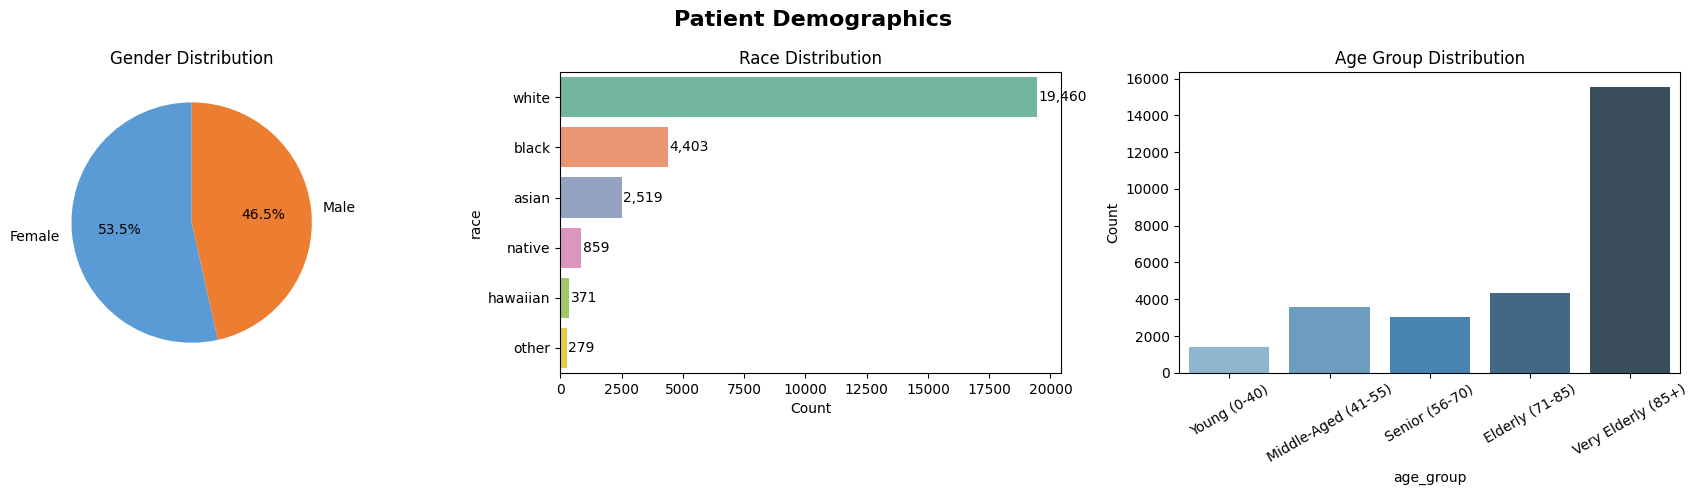

In [16]:
# EDA: Patient Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender pie
gender_data = df['gender_full'].value_counts()
axes[0].pie(gender_data.values, labels=gender_data.index, 
            autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[0].set_title('Gender Distribution')

# Race bar
race_data = df['race'].value_counts()
sns.barplot(x=race_data.values, y=race_data.index, ax=axes[1], palette='Set2')
axes[1].set_title('Race Distribution')
axes[1].set_xlabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center')

# Age group bar
age_data = df['age_group'].value_counts().sort_index()
sns.barplot(x=age_data.index, y=age_data.values, ax=axes[2], palette='Blues_d')
axes[2].set_title('Age Group Distribution')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Patient Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\3152690006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_data.values, y=class_data.index, ax=axes[1], palette='Set2')


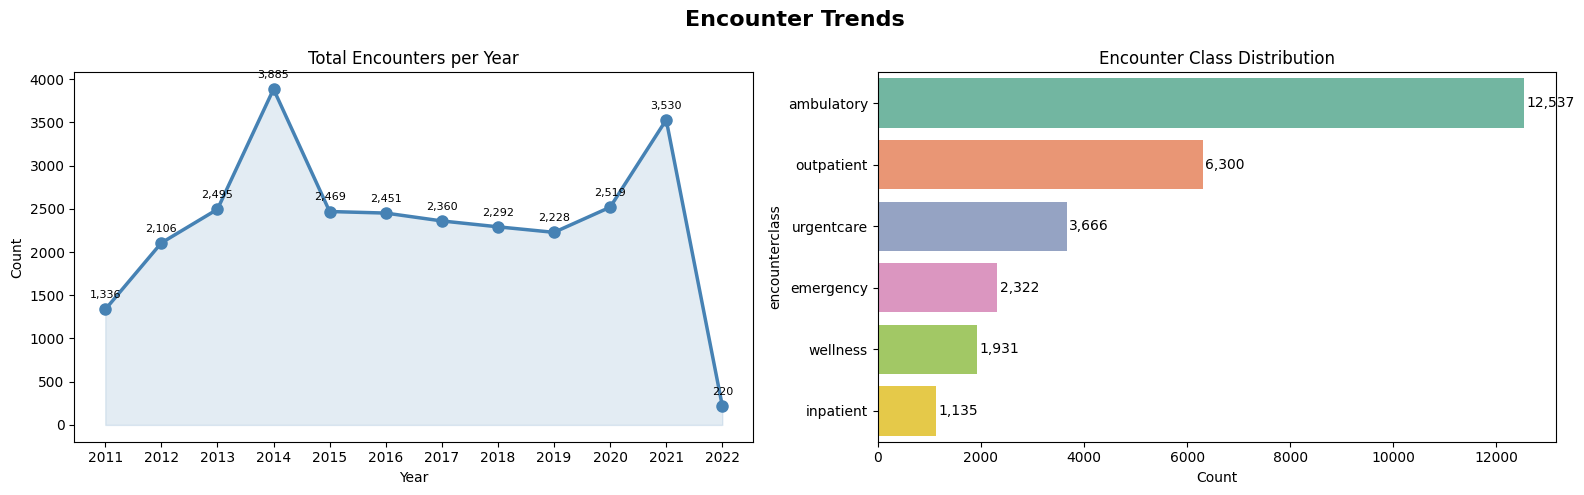

In [17]:
# EDA: Encounters Over Time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Yearly encounters
yearly = df.groupby('year').size().reset_index(name='count')
axes[0].plot(yearly['year'], yearly['count'], marker='o', 
             linewidth=2.5, color='steelblue', markersize=8)
axes[0].fill_between(yearly['year'], yearly['count'], alpha=0.15, color='steelblue')
axes[0].set_title('Total Encounters per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_xticks(yearly['year'])
for x, y in zip(yearly['year'], yearly['count']):
    axes[0].annotate(f'{y:,}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

# Encounter class breakdown
class_data = df['encounterclass'].value_counts()
sns.barplot(x=class_data.values, y=class_data.index, ax=axes[1], palette='Set2')
axes[1].set_title('Encounter Class Distribution')
axes[1].set_xlabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center')

plt.suptitle('Encounter Trends', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\4227138740.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cost.values, y=avg_cost.index, ax=axes[1], palette='Set1')
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\4227138740.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_payer.values, y=avg_payer.index, ax=axes[2], palette='coolwarm')


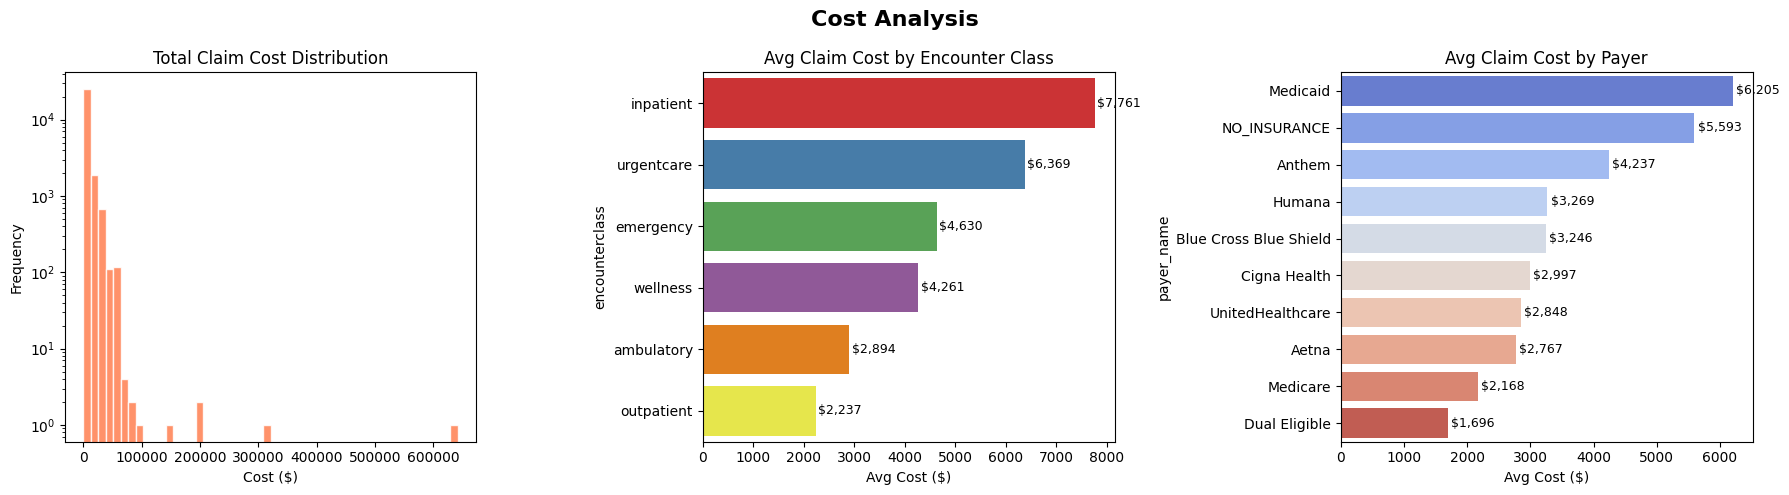

In [18]:
# EDA: Cost Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total claim cost distribution
axes[0].hist(df['total_claim_cost'], bins=50, color='coral', 
             edgecolor='white', alpha=0.85)
axes[0].set_title('Total Claim Cost Distribution')
axes[0].set_xlabel('Cost ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Avg claim cost by encounter class
avg_cost = df.groupby('encounterclass')['total_claim_cost'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cost.values, y=avg_cost.index, ax=axes[1], palette='Set1')
axes[1].set_title('Avg Claim Cost by Encounter Class')
axes[1].set_xlabel('Avg Cost ($)')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontsize=9)

# Avg cost by payer
avg_payer = df.groupby('payer_name')['total_claim_cost'].mean().sort_values(ascending=False)
sns.barplot(x=avg_payer.values, y=avg_payer.index, ax=axes[2], palette='coolwarm')
axes[2].set_title('Avg Claim Cost by Payer')
axes[2].set_xlabel('Avg Cost ($)')
for bar in axes[2].patches:
    axes[2].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontsize=9)

plt.suptitle('Cost Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\2504946198.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, ax=axes[0], palette='Blues_r')


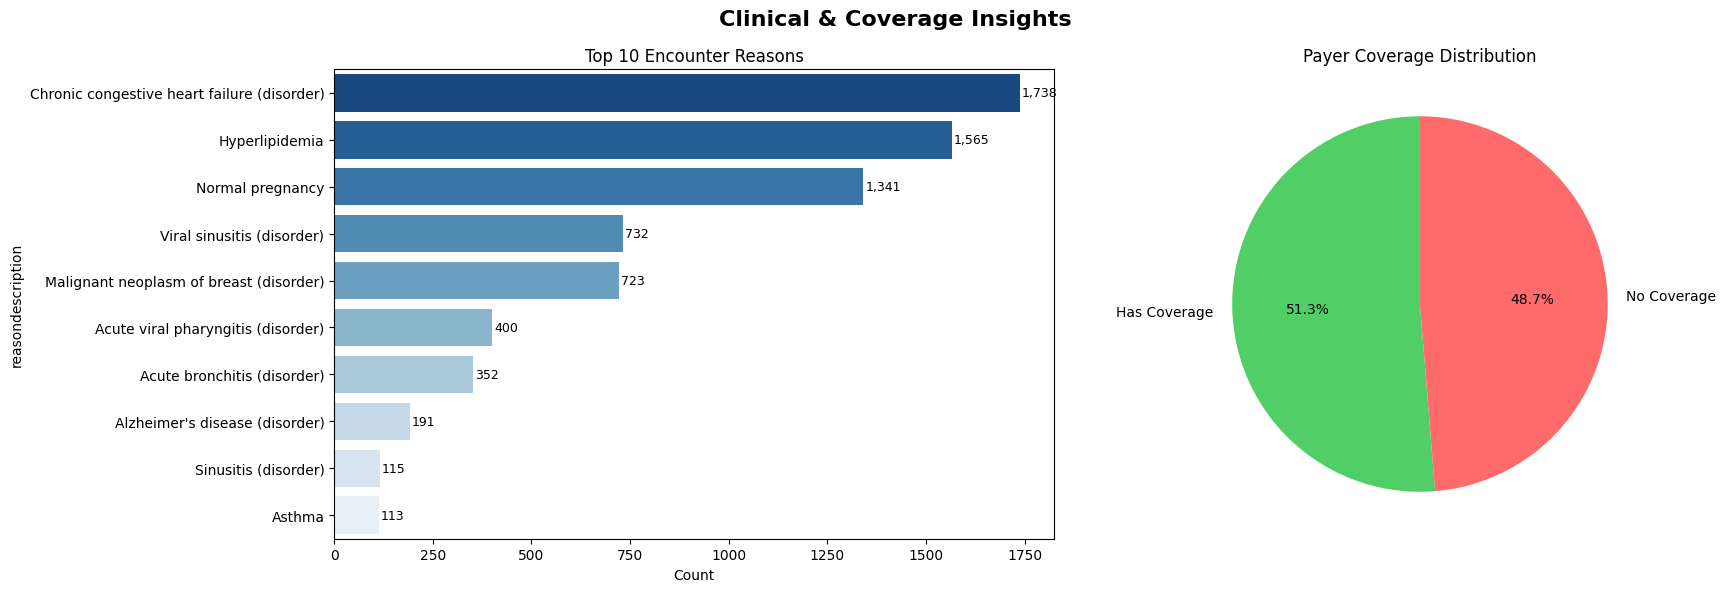

In [19]:
# EDA: Top Reasons & Payer Coverage
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 encounter reasons
top_reasons = (df[df['reasondescription'] != 'General / No Specific Reason']
               ['reasondescription'].value_counts().head(10))
sns.barplot(x=top_reasons.values, y=top_reasons.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Encounter Reasons')
axes[0].set_xlabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)

# Payer coverage — zero vs covered
cov_data = df['zero_coverage'].map({0: 'Has Coverage', 1: 'No Coverage'}).value_counts()
axes[1].pie(cov_data.values, labels=cov_data.index,
            autopct='%1.1f%%', colors=['#51CF66', '#FF6B6B'], startangle=90)
axes[1].set_title('Payer Coverage Distribution')

plt.suptitle('Clinical & Coverage Insights', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\2518086220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_procs.values, y=top_procs.index, ax=axes[0], palette='Greens_r')
C:\Users\Namrata\AppData\Local\Temp\ipykernel_20224\2518086220.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cost_procs.values, y=top_cost_procs.index, ax=axes[1], palette='Reds_r')


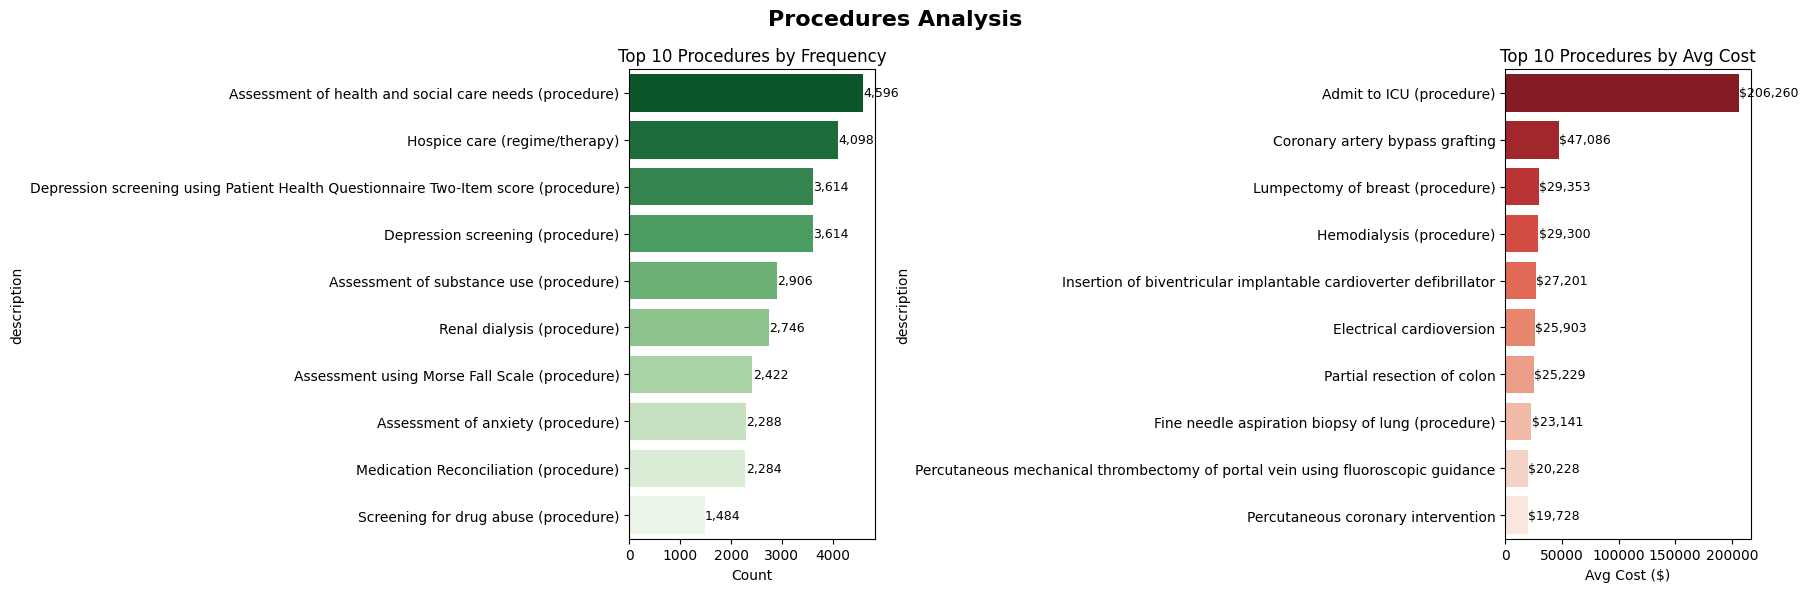

In [20]:
# EDA: Procedures Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 procedures by frequency
top_procs = procedures['description'].value_counts().head(10)
sns.barplot(x=top_procs.values, y=top_procs.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Procedures by Frequency')
axes[0].set_xlabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)

# Top 10 procedures by avg cost
top_cost_procs = (procedures.groupby('description')['base_cost']
                  .mean().sort_values(ascending=False).head(10))
sns.barplot(x=top_cost_procs.values, y=top_cost_procs.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Procedures by Avg Cost')
axes[1].set_xlabel('Avg Cost ($)')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontsize=9)

plt.suptitle('Procedures Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Export: Saving CSV for Power BI 
# Main dataset
df.to_csv('hospital_cleaned_final.csv', index=False)

# Individual cleaned tables save
patients.to_csv('patients_cleaned.csv', index=False)
procedures.to_csv('procedures_cleaned.csv', index=False)
encounters.to_csv('encounters_cleaned.csv', index=False)

print("Files saved!")
print(f"  → hospital_cleaned_final.csv  — {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  → patients_cleaned.csv        — {patients.shape[0]:,} rows × {patients.shape[1]} cols")
print(f"  → procedures_cleaned.csv      — {procedures.shape[0]:,} rows × {procedures.shape[1]} cols")
print(f"  → encounters_cleaned.csv      — {encounters.shape[0]:,} rows × {encounters.shape[1]} cols")

Files saved!
  → hospital_cleaned_final.csv  — 27,891 rows × 41 cols
  → patients_cleaned.csv        — 974 rows × 22 cols
  → procedures_cleaned.csv      — 47,701 rows × 10 cols
  → encounters_cleaned.csv      — 27,891 rows × 27 cols


In [22]:
import os
print(os.getcwd())

C:\Users\Namrata\Desktop\jupiter cllass_files
